## Ejercicio de predicción de crecimiento de población de bacterias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [22]:
# Construye un DF con las columnas:
temps = np.array([15,16,24,13,21,16,22,18,20,16,28,27,13,22,23])
humedades = np.array([70,65,71,64,84,86,72,84,71,75,84,79,80,76,88])
pob = np.array([156,157,177,145,197,184,172,187,157,169,200,193,167,170,192])

In [23]:
matriz = np.array([temps,humedades,pob])
matriz
matriz = matriz.reshape(15,3)

In [24]:
df = pd.DataFrame(matriz, columns=['Temperatura', 'Humedades', 'Pob'])
df

,Temperatura,Humedades,Pob
0,15,16,24
1,13,21,16
2,22,18,20
3,16,28,27
4,13,22,23
5,70,65,71
6,64,84,86
7,72,84,71
8,75,84,79
9,80,76,88


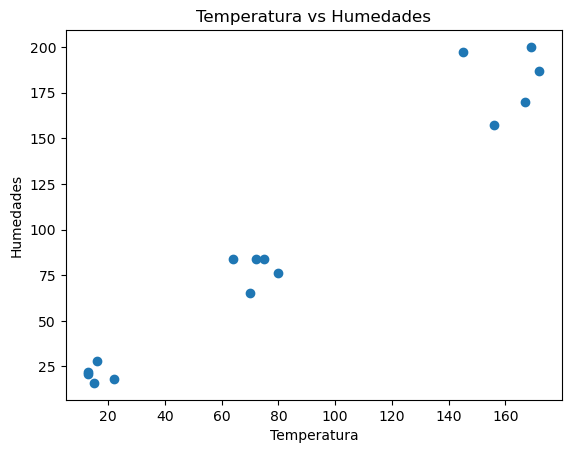

In [27]:
plt.scatter(df["Temperatura"], df["Humedades"])
plt.title("Temperatura vs Humedades")
plt.xlabel("Temperatura")
plt.ylabel("Humedades")
plt.show()

In [30]:
cor_hum_temp = df[["Temperatura", "Humedades"]].corr()
cor_hum_temp

,Temperatura,Humedades
Temperatura,1.000000,0.980252
Humedades,0.980252,1.000000


## Hay una correlación muy alta, tiene sentido porque a mayor temperatura mayor humedad, pero no creo que sea necesario eliminarlo.

In [34]:
lr = LinearRegression()
lr.fit(df[["Temperatura", "Humedades"]], df["Pob"])

LinearRegression()

In [38]:
r2 = lr.score(df[["Temperatura", "Humedades"]], df["Pob"])
r2

0.974259807514692

In [44]:
a1 = lr.coef_[0]
a2 = lr.coef_[1]
a1, a2

(np.float64(0.5649015827155892), np.float64(0.46621711031109414))

In [45]:
a0 = lr.intercept_
a0

np.float64(3.0358676506598243)

# y = a0 + a1*x1 + a2*x2

In [51]:
dic = {"Temperatura": [19], "Humedades": [23]}
df_nuevo = pd.DataFrame(dic)
df_nuevo

,Temperatura,Humedades
0,19,23


In [54]:
pob_pred = lr.predict(df_nuevo)
pob_pred

array([24.49199126])

In [55]:
df_nuevo["Pob"] = pob_pred
df_nuevo

,Temperatura,Humedades,Pob
0,19,23,24.491991
